In [6]:
import pandas as pd
import numpy as np
import os

# Define explicit paths to check based on your sidebar folders
possible_paths = [
    'archive (2)/customer_support_tickets.csv',
    'archive (3)/customer_support_tickets.csv',
    '7648117/customer_support_tickets.csv',
    'customer_support_tickets.csv'
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        try:
            # Read only a small chunk first to confirm columns match
            test_df = pd.read_csv(path, nrows=5)
            test_df.columns = test_df.columns.str.strip()
            
            # Print the actual columns found to help us debug
            print(f"📂 Found a CSV file at: {path}")
            print(f"Columns in this file: {list(test_df.columns)}")
            
            # Load the full file
            df = pd.read_csv(path)
            df.columns = df.columns.str.strip()
            break
        except Exception as e:
            print(f"Could not read {path}: {e}")

# Process the dataframe if loaded successfully
if df is not None:
    # Match columns dynamically to avoid KeyError crashes
    available = list(df.columns)
    desc_col = next((c for c in available if 'desc' in c.lower() or 'text' in c.lower() or 'complaint' in c.lower()), None)
    cat_col = next((c for c in available if 'cat' in c.lower() or 'topic' in c.lower() or 'product' in c.lower()), None)
    prio_col = next((c for c in available if 'prio' in c.lower() or 'urg' in c.lower()), None)
    
    if desc_col and cat_col:
        df = df[[desc_col, cat_col, prio_col]].dropna() if prio_col else df[[desc_col, cat_col]].dropna()
        # Rename columns to standard names for our pipeline
        df.columns = ['Ticket Description', 'Ticket Category', 'Ticket Priority'][:len(df.columns)]
        print(f"✅ Real dataset loaded successfully! Shape: {df.shape}")
    else:
        print("❌ Found a CSV but the columns inside do not match what we need.")
else:
    print("❌ Could not find a support ticket CSV file in any of your folders.")


📂 Found a CSV file at: archive (2)/customer_support_tickets.csv
Columns in this file: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']
✅ Real dataset loaded successfully! Shape: (8469, 3)


In [7]:
import nltk
from nltk.corpus import stopwords
import string

# Download text parsing rules
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # Standardize text case
    text = text.translate(str.maketrans('', '', string.punctuation)) # Wipe out punctuation
    words = text.split()
    words = [w for w in words if w not in stop_words] # Strip out fillers
    return " ".join(words)

# Apply text cleaning matrix to all 8469 tickets
df['clean_text'] = df['Ticket Description'].apply(clean_text)
print("🧼 Text preprocessing complete for all records! Sample data cleaned:")
print(df[['Ticket Description', 'clean_text']].head(2))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


🧼 Text preprocessing complete for all records! Sample data cleaned:
                                  Ticket Description  \
0  I'm having an issue with the {product_purchase...   
1  I'm having an issue with the {product_purchase...   

                                          clean_text  
0  im issue productpurchased please assist billin...  
1  im issue productpurchased please assist need c...  


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Split dataset into training sets (80%) and validation sets (20%)
X_train, X_test, y_train_cat, y_test_cat, y_train_prio, y_test_prio = train_test_split(
    df['clean_text'], df['Ticket Category'], df['Ticket Priority'], test_size=0.2, random_state=42
)

# Convert sentences into mathematical vectors
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"📊 Features extracted! Training matrix shape: {X_train_tfidf.shape}")


📊 Features extracted! Training matrix shape: (6775, 5000)


⏳ Training Category Classifier...
⏳ Training Priority Classifier...
✅ Training complete! Running evaluation...

📊 ===========================================
         CATEGORY CLASSIFICATION REPORT
                                precision    recall  f1-score   support

               Adobe Photoshop       0.03      0.03      0.03        34
                   Amazon Echo       0.11      0.12      0.11        52
                 Amazon Kindle       0.04      0.03      0.03        36
                 Apple AirPods       0.00      0.00      0.00        49
                      Asus ROG       0.00      0.00      0.00        38
              Autodesk AutoCAD       0.04      0.02      0.03        41
             Bose QuietComfort       0.00      0.00      0.00        35
        Bose SoundLink Speaker       0.06      0.05      0.06        37
             Canon DSLR Camera       0.00      0.00      0.00        44
                     Canon EOS       0.06      0.10      0.07        59
         

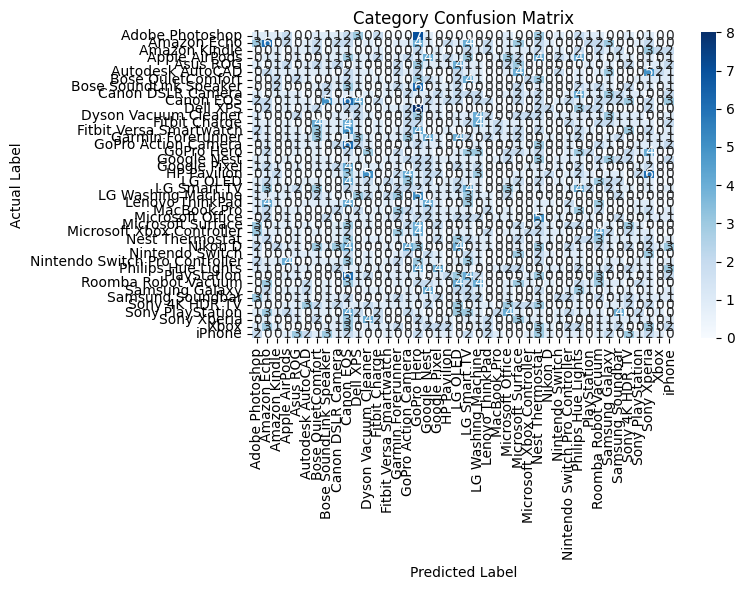

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Train the Category Classifier
print("⏳ Training Category Classifier...")
cat_model = LogisticRegression(max_iter=1000, random_state=42)
cat_model.fit(X_train_tfidf, y_train_cat)

# 2. Train the Priority Classifier
print("⏳ Training Priority Classifier...")
prio_model = LogisticRegression(max_iter=1000, random_state=42)
prio_model.fit(X_train_tfidf, y_train_prio)

print("✅ Training complete! Running evaluation...\n")

# 3. Predict on the Test Set
cat_preds = cat_model.predict(X_test_tfidf)
prio_preds = prio_model.predict(X_test_tfidf)

# 4. Print Business Performance Reports
print("📊 ===========================================")
print("         CATEGORY CLASSIFICATION REPORT")
print("===========================================")
print(classification_report(y_test_cat, cat_preds, zero_division=0))

print("\n🚨 ===========================================")
print("         PRIORITY CLASSIFICATION REPORT")
print("===========================================")
print(classification_report(y_test_prio, prio_preds, zero_division=0))

# 5. Plot and display Confusion Matrix for Category
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_cat, cat_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cat_model.classes_, 
            yticklabels=cat_model.classes_)
plt.title('Category Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [10]:
import joblib

# Save the models and vectorizer to files
joblib.dump(cat_model, 'category_classifier_model.pkl')
joblib.dump(prio_model, 'priority_classifier_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("💾 All components saved successfully to your project folder!")


💾 All components saved successfully to your project folder!


In [11]:
def classify_incoming_ticket(ticket_text):
    # Process text using the vectorizer
    features = vectorizer.transform([ticket_text])
    
    # Predict category and priority
    predicted_product = cat_model.predict(features)[0]
    predicted_urgency = prio_model.predict(features)[0]
    
    print(f"\n📥 Incoming Ticket: '{ticket_text}'")
    print(f"📦 Identified Product: {predicted_product}")
    print(f"🚨 Priority Level: {predicted_urgency}")

# Test with a sample text string
classify_incoming_ticket("My nintendo switch screen is completely frozen and won't turn on.")



📥 Incoming Ticket: 'My nintendo switch screen is completely frozen and won't turn on.'
📦 Identified Product: MacBook Pro
🚨 Priority Level: Medium
